# Lab 10 - Implementing Deep Learning Neural Network, CNN1

# Convolutional Neural Network (CNN)

Convolutional Neural Network (CNN) is used in many neural network applications. CNN is now very common in computer vision area such as image classification, object detection and instance segmentation. CNN can be also applied in problem dealing with structured data such as time series and medical image analytics. In this lab, you will learn the followings:

1. Using small dataset from Keras in training CNN
2. Handling image with matplot library
3. Understanding TensorFlow tensors
4. Implementing a Convolutional Neural Network

Instruction to complete lab exercises:

1. Open python notebook file under Lab folder
2. Read the problem statement in the exercise and expected output
3. Uncomment and remove the lines and fill in your answer
4. Run your code to produce expected output.

Noted: Data files are stored in dataset folder

# Using small dataset from Keras in training CNN

The tf.keras.datasets module provide a few small datasets. The datasets are vectorized, in Numpy format that can be used for debugging a model or creating simple code examples. In this exercise, load and understand different types of small datasets.

- MNIST digits classification dataset:
This is the dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

- CIFAR10, CIFAR100 small images classification dataset
This is the dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories. 

- IMDB movie review sentiment classification dataset
This is the dataset of 25,000 movies reviews from IMDB, labeled by sentiment (positive/negative). Reviews have been preprocessed, and each review is encoded as a list of word indexes (integers)

- Fashion MNIST dataset, an alternative to MNIST
This is the dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images.

- Boston Housing price regression dataset
This dataset contains 13 attributes of houses at different locations around the Boston suburbs in the late 1970s. Targets are the median values of the houses at a location.


All the datasets have load_data function which returns train and test sets of data. The binary data of the images are stored in npz format. If you know the file name of npz, you can use the file name to load the data as well.

- datasets.mnist.load_data()
or
- datasets.mnist.load_data(path="mnist.npz")

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
import tensorflow as tf
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()
#or
#(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data(path="mnist.npz")
print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


# Load the data from fashion_mnist dataset and display dimension of the train and test data 

In [5]:

(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)

print(Y_train.shape)
print(Y_test.shape)


(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


# Handling image with matplot library

matplotlib.pyplot library has two functions imread and imshow handle and display data as an image, i.e., on a 2D regular raster. The input may either be actual RGB(A) data, or 2D scalar data, which will be rendered as a pseudocolor image. For displaying a grayscale image set up the colormapping using the parameters cmap='gray', vmin=0, vmax=255.

The image file can be read using imread function of the matplotlib.pyplot. It returns np array of the image based on image type.

- (M, N) for grayscale images.
- (M, N, 3) for RGB images.
- (M, N, 4) for RGBA images.

The image data in a numpy array either by importing it, or by generating it can be plot as image using imgshow function of the matplotlib.pyplot. 

First parameter X in imshow function is the array-like or PIL image.

[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]


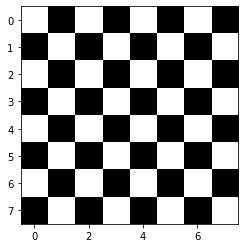

In [6]:
import numpy as np
import matplotlib.pyplot as plt
 
# create a 8x8 matrix of two numbers-0 and 1. 
arr=np.array([[1,0]*4,[0,1]*4]*4)
print(arr)

# use the imshow function to display the image made from the above array
plt.imshow(arr, cmap="gray")

(480, 640, 3)


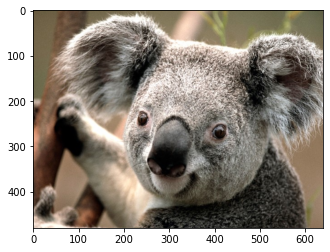

In [8]:
import matplotlib.pyplot as plt
# read the image
pix=plt.imread("./images/koala.jpg")
#display the shape of image data
print(pix.shape)
#print(pix)
#display the image
plt.imshow(pix)

# Exercise 1:

Load and display the image bird.png and display the information such as size and image in grayscale as shown.

Note: To display the image as grayscale, we only need one color channel. 

(443, 590, 3)


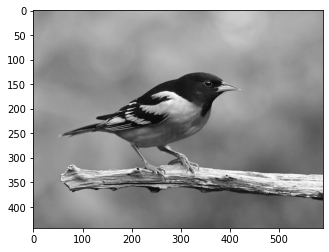

In [9]:
import matplotlib.pyplot as plt

# load the image
pix= plt.imread("./images/bird.png")

#display the shape of image data
print(pix.shape)

#display the grey scale image
plt.imshow(pix[: , :, 1] , cmap='gray')


# Understanding TensorFlow tensors

TensorFlow is a framework to define and run computations involving tensors. A tensor is a generalization of vectors and matrices to potentially higher dimensions. Internally, TensorFlow represents tensors as n-dimensional arrays of base datatypes.

- Shape: The length (number of elements) of each of the axes of a tensor.
- Rank: Number of tensor axes. A scalar has rank 0, a vector has rank 1, a matrix is rank 2.
- Axis or Dimension: A particular dimension of a tensor.
- Size: The total number of items in the tensor, the product shape vector.

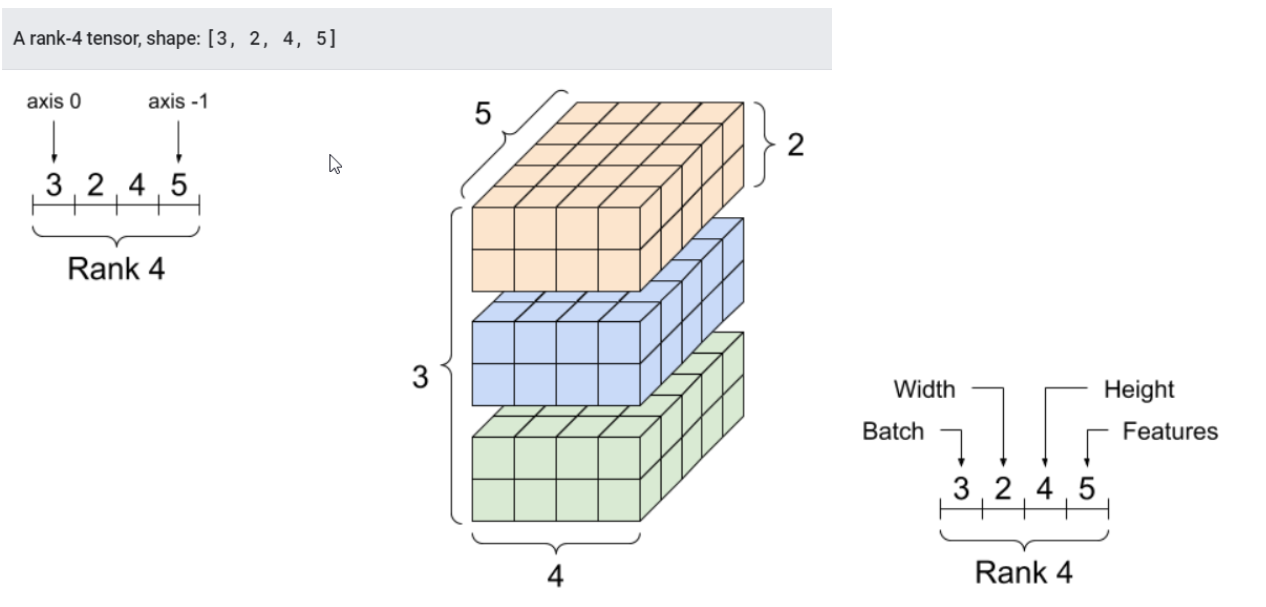

You can create rank 4 tensor as follow:

- import tensorflow as tf
- tf.zeros([3, 2, 4, 5])

Existing numpby n-dimension array can be convert into tenson shape by using reshape function.

- X_train.reshape(60000, 28, 28, 1)

Ref: https://www.tensorflow.org/guide/tensor

In [10]:
import tensorflow as tf
rank_4_tensor = tf.zeros([3, 2, 4, 5])

print("Type of every element:", rank_4_tensor.dtype)
print("Number of axes:", rank_4_tensor.ndim)
print("Shape of tensor:", rank_4_tensor.shape)
print("Elements along axis 0 of tensor:", rank_4_tensor.shape[0])
print("Elements along the last axis of tensor:", rank_4_tensor.shape[-1])
print("Total number of elements (3*2*4*5): ", tf.size(rank_4_tensor).numpy())

Type of every element: <dtype: 'float32'>
Number of axes: 4
Shape of tensor: (3, 2, 4, 5)
Elements along axis 0 of tensor: 3
Elements along the last axis of tensor: 5
Total number of elements (3*2*4*5):  120


# Implementing a Deep Neural Network, CNN

Solve the hand-written digit recognition problem using CNN. This is the classic example of the multi-class classification for image data. We use the prepared data from mnist from keras datasets. Data has hand-written digits from 0 to 9 in grayscale 28 x 28 image format. Data will be trained using CNN model to classify the output as one of the digit (0 - 9). If we use the softmax as our activation function in the last layer. The result will be 10 outputs of the probabilities with sum of 1. Exercise will implement the following steps.

1. Load the digit images data from keras mnist dataset 
2. Normalize the image data
3. Define the CNN Model
4. Compile and Fit the Model
5. Evaluate the accuracy of the Model
6. Test the model with input data


In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the digit images data from keras mnist dataset 

Load the data from MNIST digits classification dataset. It contains 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images. The original dataset has three dimensions. It needs to reshape into tensor image format eg. (60000, 28, 28, 1)

# Define the 10 digits as class_name

In [15]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Load the data from mnist and reshape to tensor shape

In [16]:
# Load the data from mnist dataset

(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

# Reshape to tensors format

train_images = X_train.reshape(60000, 28, 28, 1)
test_images = X_test.reshape(10000, 28, 28, 1)

train_labels1 = Y_train.reshape(60000, 1)
test_labels1 = Y_test.reshape(10000, 1)

# Display the tensor shape of train images

#print(train_images.size)
#print(train_images.ndim)
#print(train_images.shape)
#print(train_images.shape[0])
#print(train_images.shape[-1])


# Encode the label Y_train and Y_test with Onehot encoder

# Use to_categorical function from np_utils 

Note if you are unable to encode with Onehot encoder, the loss function needs to use with SparseCatergoricalCrossentropy otherwise use CatergoricalCrossentropy.

# Display the shape of train label as (60000, 10)

In [18]:
train_labels = to_categorical(Y_train, 10)
test_labels = to_categorical(Y_test, 10)
print(train_labels.shape)

(60000, 10)


# Normalize pixel values to be between 0 and 1

All the images pixels are from int 0 - 255. All the data needs to divide by 255.0 to normalize the image data.
Display the normalized image using matplot.

In [19]:
train_images, test_images = train_images / 255.0, test_images / 255.0

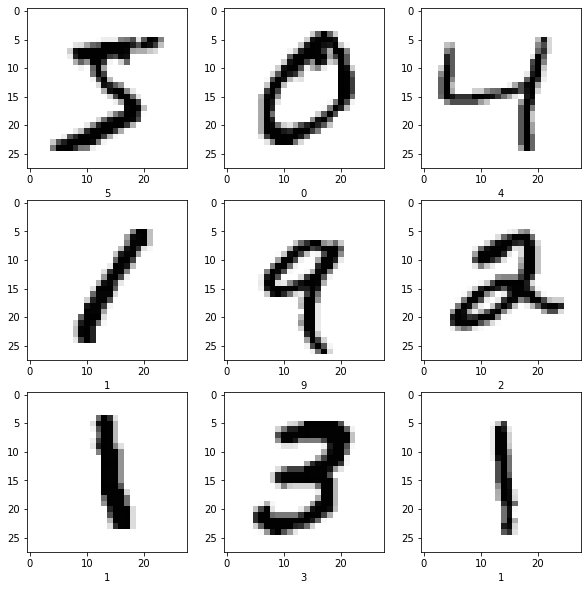

In [20]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)    
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels1[i][0]])
plt.show()

# Define the CNN model

Define the CNN Model with following model parameters

1. Input layer with the shape of 28 x 28 x 1 image
2. Two layers of 2D Convolution: 32 number of kernels, kernels of 3 x 3 with Relu as activation function
3. One MaxPooling2D layer 2 x 2
4. Flatten
5. A dense layer with 64 number of kernels with Relu
6. Final dense layer with 10 number of kernels with softmax activation

Note: Softmax function is used to make sure all 10 predicted outputs (probabilities) will sum up to 1

Summary of CNN model:

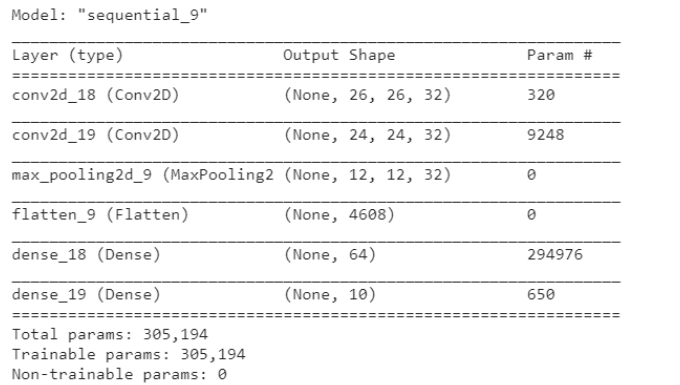

In [21]:
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 4608)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                294976    
_________________________________________________________________
dense_1 (Dense)              (None, 10)                650       
Total params: 305,194
Trainable params: 305,194
Non-trainable params: 0
__________________________________________________

# Compile and Fit the model

Model will be compiled using adam optimizer and categorical_crossentropy loss function. categorical_crossentropy is suitable for the categorical data that are encoded using with onehot encoder.

Train or fit the model with training images and labels for 10 epochs.

In [22]:
model.compile(loss=tf.keras.losses.categorical_crossentropy, metrics=['accuracy'], optimizer='adam')


In [23]:
history = model.fit(train_images, train_labels, epochs=10, batch_size=100, validation_data=(test_images, test_labels))


Epoch 1/10
600/600 [==============================] - 30s 50ms/step - loss: 0.1851 - accuracy: 0.9467 - val_loss: 0.0660 - val_accuracy: 0.9808
Epoch 2/10
600/600 [==============================] - 30s 50ms/step - loss: 0.0487 - accuracy: 0.9851 - val_loss: 0.0410 - val_accuracy: 0.9860
Epoch 3/10
600/600 [==============================] - 32s 53ms/step - loss: 0.0345 - accuracy: 0.9893 - val_loss: 0.0378 - val_accuracy: 0.9872
Epoch 4/10
600/600 [==============================] - 31s 51ms/step - loss: 0.0235 - accuracy: 0.9926 - val_loss: 0.0310 - val_accuracy: 0.9889
Epoch 5/10
600/600 [==============================] - 31s 51ms/step - loss: 0.0176 - accuracy: 0.9945 - val_loss: 0.0421 - val_accuracy: 0.9862
Epoch 6/10
600/600 [==============================] - 31s 52ms/step - loss: 0.0125 - accuracy: 0.9961 - val_loss: 0.0334 - val_accuracy: 0.9900
Epoch 7/10
600/600 [==============================] - 30s 51ms/step - loss: 0.0107 - accuracy: 0.9966 - val_loss: 0.0463 - val_accuracy:

# Evaluate the accuracy of the Model


In [24]:
# Evaluate the model
scores = model.evaluate(test_images, test_labels, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Accuracy: 98.95%


# Test the model with input data 
 
Input data can be any hand-written digit image, the image needs to be in 28 x 28 x 1 dimension. Alternatively, we can select one of the images from test_images and predict. Predicted output will be 10 probabilities of the independent classes, using the np.argmax function to inverse back. 

eg. np.argmax(predict[1])

Compare the predicted output with the test image.

This image most likely belongs to 4 with a 100.00 percent confidence.


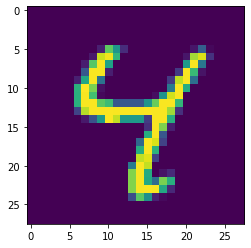

In [26]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

predict = model.predict(test_images[:10])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(predict[6])], 100 * np.max(predict))
)

# The original image
plt.imshow(test_images[6])

# Exercie 2:

Classify the images from keras fashion mnist dataset. Fashion MNIST dataset, an alternative to MNIST This is the dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images.

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Define the 10 digits as class_name

In [28]:
#class_names = [___________________________________________________________]

# Load the data from fashion mnist and reshape to tensor shape
# Display the shape, size, dimension of train images

In [30]:
#(X_train, Y_train), (X_test, Y_test) = _____________________________________________


#train_images = _____________________________________

#test_images = _____________________________________

#train_labels = _____________________________________

#test_labels = _____________________________________

#print(train_images.size)
#print(train_images.ndim)
#print(train_images.shape)
#print(train_images.shape[0])
#print(train_images.shape[-1])

#print(train_labels.shape)

47040000
4
(60000, 28, 28, 1)
60000
1
(60000, 1)


# Normalize pixel values to be between 0 and 1

All the images pixels are from int 0 - 255. All the data needs to divide by 255.0 to normalize the image data.
Display the normalized image using matplot.

In [32]:
#train_images, test_images = _____________________________________


# Display the train images of 3x3 images with corresponding labels

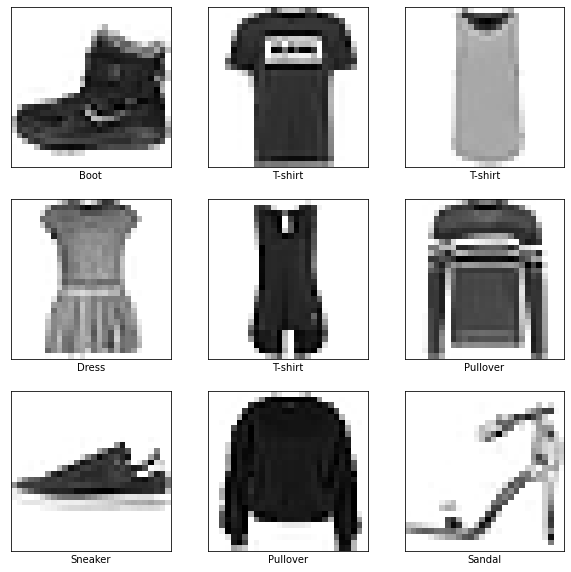

In [33]:
#plt.figure(figsize=(10,10))
#for i in range(9):
    #plt.subplot(_____________________________________)
    #plt.grid(False)
    #plt.imshow(___________________, _________________________)
    
    #plt.xlabel(____________________________________)

#plt.show()

# Define the CNN model

Define the CNN Model with following model parameters

1. Input layer with the shape of 28 x 28 x 1 image
2. One layers of 2D Convolution: 32 number of kernels, kernels of 3 x 3 with Relu as activation function
3. One layers of 2D Convolution: 62 number of kernels, kernels of 3 x 3 with Relu as activation function
4. One MaxPooling2D layer 2 x 2
5. Flatten
6. A dense layer with 64 number of kernels with Relu
7. Final dense layer with 10 number of kernels with softmax activation

Note: Softmax function is used to make sure all 10 predicted outputs (probabilities) will sum up to 1

Summary of CNN model:

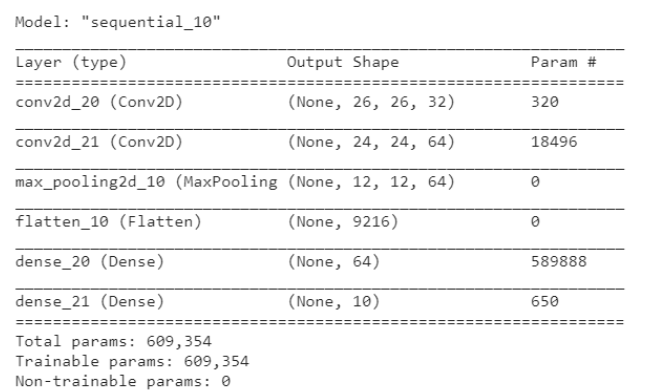

In [40]:

model = _____________________________________

model.add(_____________________________________)

model.add(_____________________________, ____________________)

model.add(_____________________________, ____________________)

model.add(__________________________________________)

model.add(__________________________________________)

model.add(__________________________________________)

model.add(__________________________________________)

print(model.summary())

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_7 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 64)                589888    
_________________________________________________________________
dense_5 (Dense)              (None, 10)                650       
Total params: 609,354
Trainable params: 609,354
Non-trainable params: 0
________________________________________________

# Compile and Fit the model

Model will be compiled using adam optimizer and SparseCategoricalCrossentropy loss function. SparseCategoricalCrossentropy is suitable for the categorical data that are represented in integer number (eg. 1, 2, 3 ..)

Train or fit the model with training images and labels for 10 epochs.

In [41]:

#model.compile(______________________, _______________________________________, ___________________)


In [42]:

#history = model.fit(______________, _______________, ______________, batch_size=100,  validation_data=(test_images, test_labels))


Epoch 1/10
600/600 [==============================] - 40s 67ms/step - loss: 1.7408 - accuracy: 0.7231 - val_loss: 1.7113 - val_accuracy: 0.7503
Epoch 2/10
600/600 [==============================] - 38s 64ms/step - loss: 1.7061 - accuracy: 0.7552 - val_loss: 1.7083 - val_accuracy: 0.7534s: 1
Epoch 3/10
600/600 [==============================] - 40s 66ms/step - loss: 1.6993 - accuracy: 0.7613 - val_loss: 1.6991 - val_accuracy: 0.7607
Epoch 4/10
600/600 [==============================] - 38s 64ms/step - loss: 1.6210 - accuracy: 0.8405 - val_loss: 1.5805 - val_accuracy: 0.8815
Epoch 5/10
600/600 [==============================] - 39s 65ms/step - loss: 1.5680 - accuracy: 0.8939 - val_loss: 1.5898 - val_accuracy: 0.8718
Epoch 6/10
600/600 [==============================] - 38s 63ms/step - loss: 1.5550 - accuracy: 0.9068 - val_loss: 1.5665 - val_accuracy: 0.8948
Epoch 7/10
600/600 [==============================] - 39s 65ms/step - loss: 1.5482 - accuracy: 0.9137 - val_loss: 1.5613 - val_accur

# Evaluate the accuracy of the Model


In [43]:
# Evaluate the model

#scores = model.evaluate(___________, _______________, ______________)

#print("Accuracy: %.2f%%" % (scores[1]*100))


Accuracy: 90.95%


# Exercise 3:

Test the model with input image data. Input data can be any fashion design image, the image needs to be in 28 x 28 x 1 dimension. Alternatively, we can select one of the images from test_images and predict. Predicted output will be 10 probabilities of the independent classes, use the np.argmax function to inverse back. 

eg. np.argmax(predict[1])

Compare the predicted output with the test image.

This image most likely belongs to Trouser with a 100.00 percent confidence.


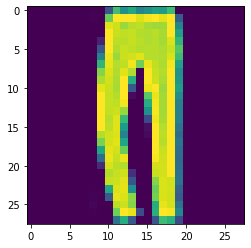

In [44]:

#class_names = [_____________________________________________________________________]

#predict = ______________________________________

#print(
 #   "This image most likely belongs to {} with a {:.2f} percent confidence."
  #  .format(_____________________________, ________________________)
#)

# The original image
#plt.imshow(______________________)